<a href="https://colab.research.google.com/github/LanaCoded/data-analysis-/blob/main/Rossmann_Store_Sales_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [66]:
import zipfile
import pandas as pd

# Path to the zip file for training data
train_zip_file_path = '/content/train.csv.zip'

# Open the zip file in read mode
with zipfile.ZipFile(train_zip_file_path, 'r') as zf:
    # Get a list of all files in the zip archive
    file_list = zf.namelist()
    print(f"Files in '{train_zip_file_path}': {file_list}")

    # Assuming the CSV is directly inside the zip with the same name (minus .zip)
    csv_file_name = 'train.csv'
    if csv_file_name in file_list:
        # Read the CSV directly into a pandas DataFrame, specifying dtype for 'StateHoliday'
        with zf.open(csv_file_name) as csv_file:
            train_df = pd.read_csv(csv_file, dtype={'StateHoliday': str})
        print(f"'{csv_file_name}' loaded into 'train_df'.")
        display(train_df.head())
    else:
        print(f"Error: '{csv_file_name}' not found in '{train_zip_file_path}'.")

Files in '/content/train.csv.zip': ['train.csv']
'train.csv' loaded into 'train_df'.


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [67]:
# Path to the zip file for test data
test_zip_file_path = '/content/test.csv.zip'

# Open the zip file in read mode
with zipfile.ZipFile(test_zip_file_path, 'r') as zf:
    file_list = zf.namelist()
    print(f"Files in '{test_zip_file_path}': {file_list}")

    csv_file_name = 'test.csv'
    if csv_file_name in file_list:
        with zf.open(csv_file_name) as csv_file:
            test_df = pd.read_csv(csv_file)
        print(f"'{csv_file_name}' loaded into 'test_df'.")
        display(test_df.head())
    else:
        print(f"Error: '{csv_file_name}' not found in '{test_zip_file_path}'.")

Files in '/content/test.csv.zip': ['test.csv']
'test.csv' loaded into 'test_df'.


,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [68]:
store = pd.read_csv("/content/store.csv")
store

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [69]:
train_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1
1017205,1112,2,2013-01-01,0,0,0,0,a,1
1017206,1113,2,2013-01-01,0,0,0,0,a,1
1017207,1114,2,2013-01-01,0,0,0,0,a,1


In [70]:
train_df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [71]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [72]:
merged_df = pd.merge(train_df, store, on="Store", how="left")
merged_df.describe()

# one to many join

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


In [73]:
merged_df["CustomerSpendings"] = merged_df["Sales"] / merged_df["Customers"]

In [74]:
merged_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CustomerSpendings
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN,9.482883
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",9.702400
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",10.126675
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN,9.342457
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN,8.626118


In [75]:
merged_df["Date"] = pd.to_datetime(merged_df["Date"])

# 2. Extract the year
merged_df["year"] = merged_df["Date"].dt.year
merged_df['month'] = merged_df['Date'].dt.month
merged_df['day'] = merged_df['Date'].dt.day
merged_df['weekofyear'] = merged_df['Date'].dt.isocalendar().week.astype(int)


print("New temporal features added: month, day, weekofyear")
display(merged_df[['Date', 'year', 'month', 'day', 'weekofyear']].head())

New temporal features added: month, day, weekofyear


,Date,year,month,day,weekofyear
0,2015-07-31,2015,7,31,31
1,2015-07-31,2015,7,31,31
2,2015-07-31,2015,7,31,31
3,2015-07-31,2015,7,31,31
4,2015-07-31,2015,7,31,31


In [76]:
# 1. Define all 12 months in order
all_months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# 2. Get dummies and force all 12 columns (filling missing ones with 0)
dummies = (
    merged_df["PromoInterval"]
    .str.get_dummies(sep=",")
    .reindex(columns=all_months, fill_value=0)
)

# 3. Join it back to your original dataframe
merged_df = merged_df.join(dummies)

In [77]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 35 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [78]:
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,0,0,0,0,0,0,0,0,0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,0,1,0,0,1,0,0,1,0,0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,0,1,0,0,1,0,0,1,0,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,0,0,0,0,0,0,0,0,0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,...,0,1,0,0,1,0,0,1,0,0
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,...,0,0,0,0,0,0,0,0,0,0
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,...,0,0,0,0,0,0,0,0,0,0
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,...,0,0,0,0,0,0,0,0,0,0


In [79]:
merged_df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [80]:
merged_df["CompetitionDistance"] = merged_df["CompetitionDistance"].fillna(merged_df["CompetitionDistance"].mean())
merged_df["CompetitionOpenSinceMonth"] = merged_df["CompetitionOpenSinceMonth"].fillna(merged_df["CompetitionOpenSinceMonth"].mean())
merged_df["CompetitionOpenSinceYear"] = merged_df["CompetitionOpenSinceYear"].fillna(merged_df["CompetitionOpenSinceYear"].mean())
merged_df["Promo2SinceWeek"] = merged_df["Promo2SinceWeek"].fillna(merged_df["Promo2SinceWeek"].mean())
merged_df["Promo2SinceYear"] = merged_df["Promo2SinceYear"].fillna(merged_df["Promo2SinceYear"].mean())


merged_df["PromoInterval"] = merged_df["PromoInterval"].fillna("None")
# .mode()[0] grabs the single most frequent string in that column
most_frequent = merged_df["PromoInterval"].mode()[0]
merged_df["PromoInterval"] = merged_df["PromoInterval"].fillna(most_frequent)



merged_df["CustomerSpendings"] = merged_df["CustomerSpendings"].fillna(0)
merged_df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,0,0,0,0,0,0,0,0,0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,0,1,0,0,1,0,0,1,0,0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,0,1,0,0,1,0,0,1,0,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,0,0,0,0,0,0,0,0,0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,...,0,1,0,0,1,0,0,1,0,0
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,...,0,0,0,0,0,0,0,0,0,0
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,...,0,0,0,0,0,0,0,0,0,0
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,...,0,0,0,0,0,0,0,0,0,0


In [81]:
merged_df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [82]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
categorical_cols = ['StoreType', 'Assortment', 'StateHoliday']

for col in categorical_cols:
    merged_df[col] = le.fit_transform(merged_df[col].astype(str))

print("Unique values after encoding:")
for col in categorical_cols:
    print(f"{col}: {merged_df[col].unique()}")

display(merged_df.head())

Unique values after encoding:
StoreType: [2 0 3 1]
Assortment: [0 2 1]
StateHoliday: [0 1 2 3]


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1,5,2015-07-31,5263,555,1,1,0,1,2,...,0,0,0,0,0,0,0,0,0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0
2,3,5,2015-07-31,8314,821,1,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0
3,4,5,2015-07-31,13995,1498,1,1,0,1,2,...,0,0,0,0,0,0,0,0,0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


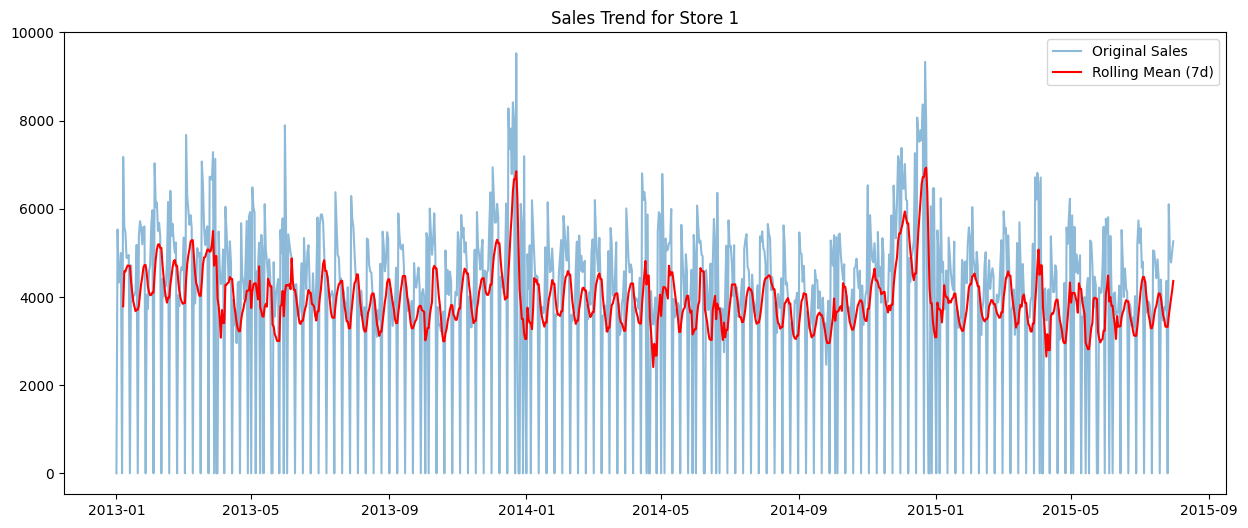

In [85]:
def get_rolling_stats(df, window=7):
    """Calculates rolling mean and std for Sales."""
    rolling_mean = df['Sales'].rolling(window=window).mean()
    rolling_std = df['Sales'].rolling(window=window).std()
    return rolling_mean, rolling_std

def plot_time_series(df, store_id=1):
    """Plots Sales and rolling mean for a specific store."""
    store_data = df[df['Store'] == store_id].sort_values('Date')
    rolling_mean, _ = get_rolling_stats(store_data)

    plt.figure(figsize=(15, 6))
    plt.plot(store_data['Date'], store_data['Sales'], label='Original Sales', alpha=0.5)
    plt.plot(store_data['Date'], rolling_mean, label=f'Rolling Mean (7d)', color='red')
    plt.title(f'Sales Trend for Store {store_id}')
    plt.legend()
    plt.show()

# Example usage for Store 1
plot_time_series(merged_df, store_id=1)

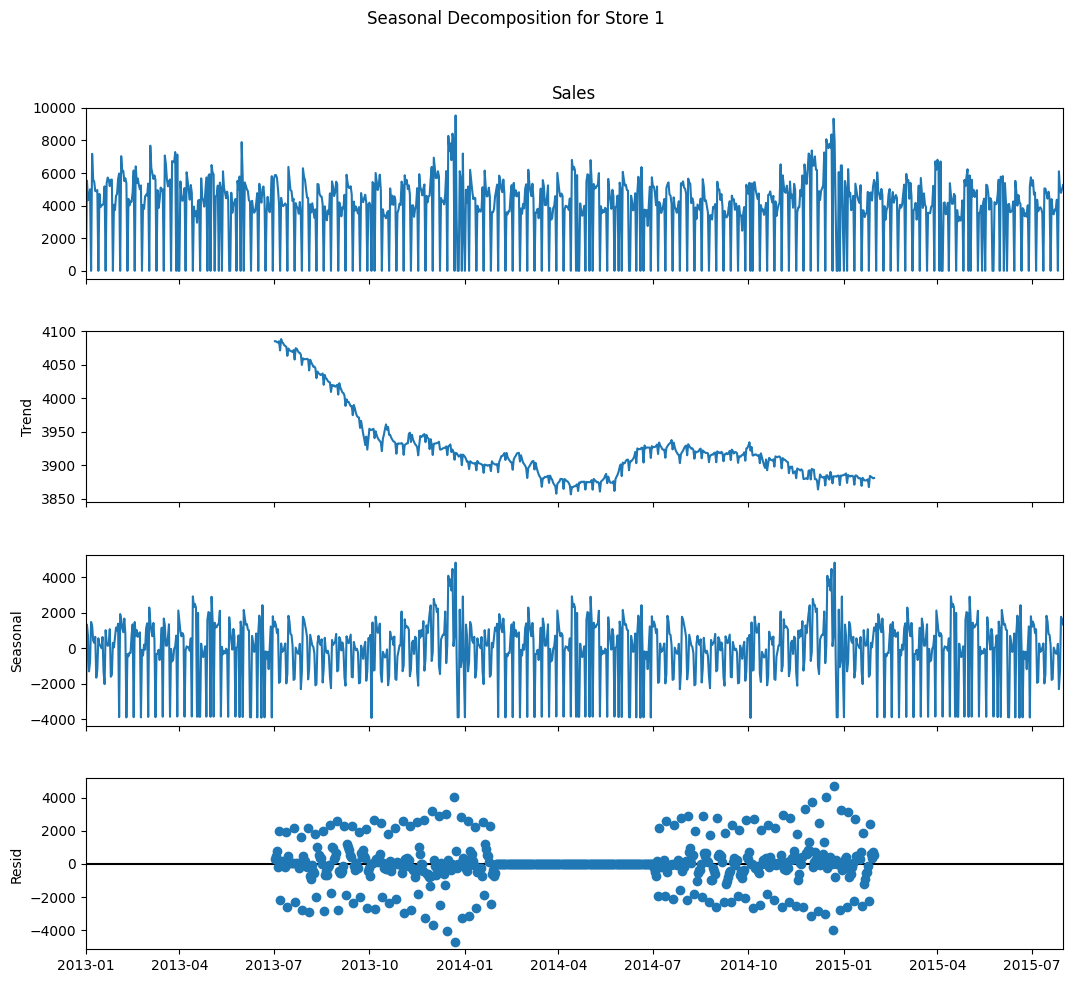

In [86]:
from statsmodels.tsa.seasonal import seasonal_decompose

def decompose_sales(df, store_id=1, model='additive', period=365):
    """Performs seasonal decomposition for a specific store."""
    store_data = df[df['Store'] == store_id].sort_values('Date')
    store_data.set_index('Date', inplace=True)

    # Resample to daily to ensure a continuous time series for decomposition
    daily_sales = store_data['Sales'].resample('D').mean().fillna(0)

    decomposition = seasonal_decompose(daily_sales, model=model, period=period)

    fig = decomposition.plot()
    fig.set_size_inches(12, 10)
    plt.suptitle(f'Seasonal Decomposition for Store {store_id}', y=1.02)
    plt.show()

# Example decomposition for Store 1
decompose_sales(merged_df, store_id=1)

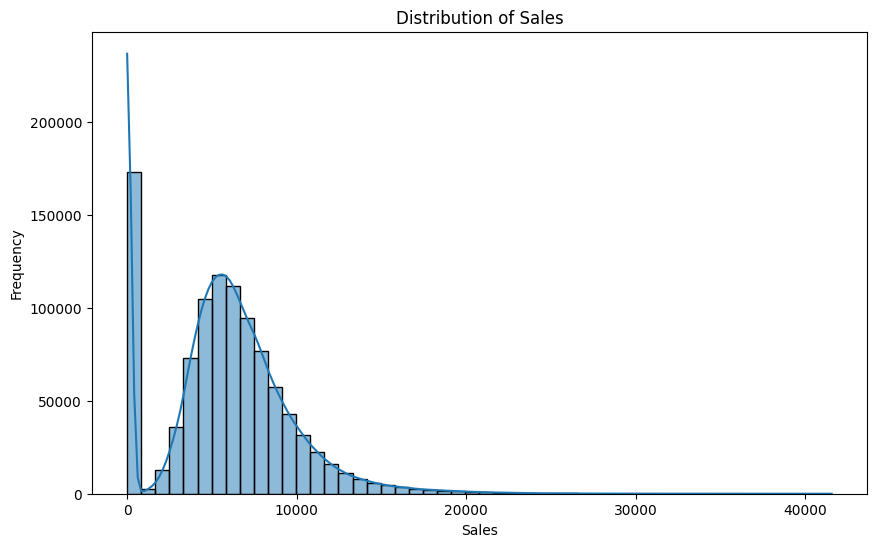

Sales Skewness: 0.6414596158103787


In [87]:
plt.figure(figsize=(10, 6))
sns.histplot(merged_df['Sales'], bins=50, kde=True)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

# Calculate skewness
print(f"Sales Skewness: {merged_df['Sales'].skew()}")

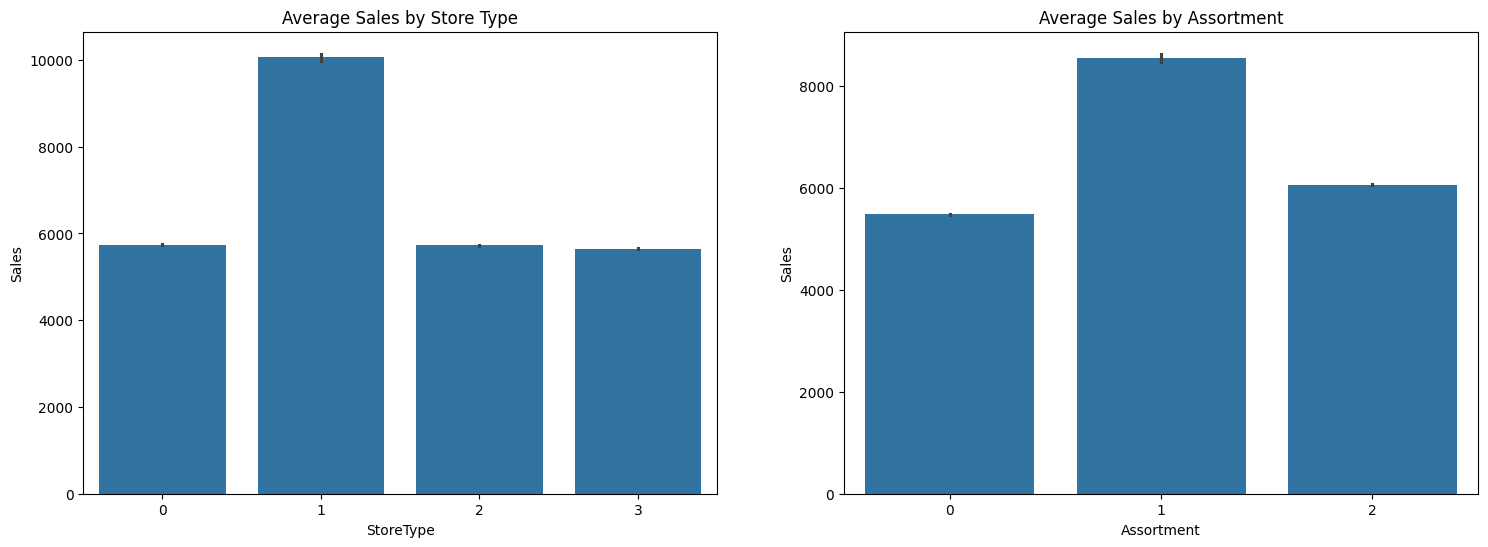

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Sales by StoreType
sns.barplot(x='StoreType', y='Sales', data=merged_df, ax=axes[0])
axes[0].set_title('Average Sales by Store Type')

# Sales by Assortment
sns.barplot(x='Assortment', y='Sales', data=merged_df, ax=axes[1])
axes[1].set_title('Average Sales by Assortment')

plt.show()

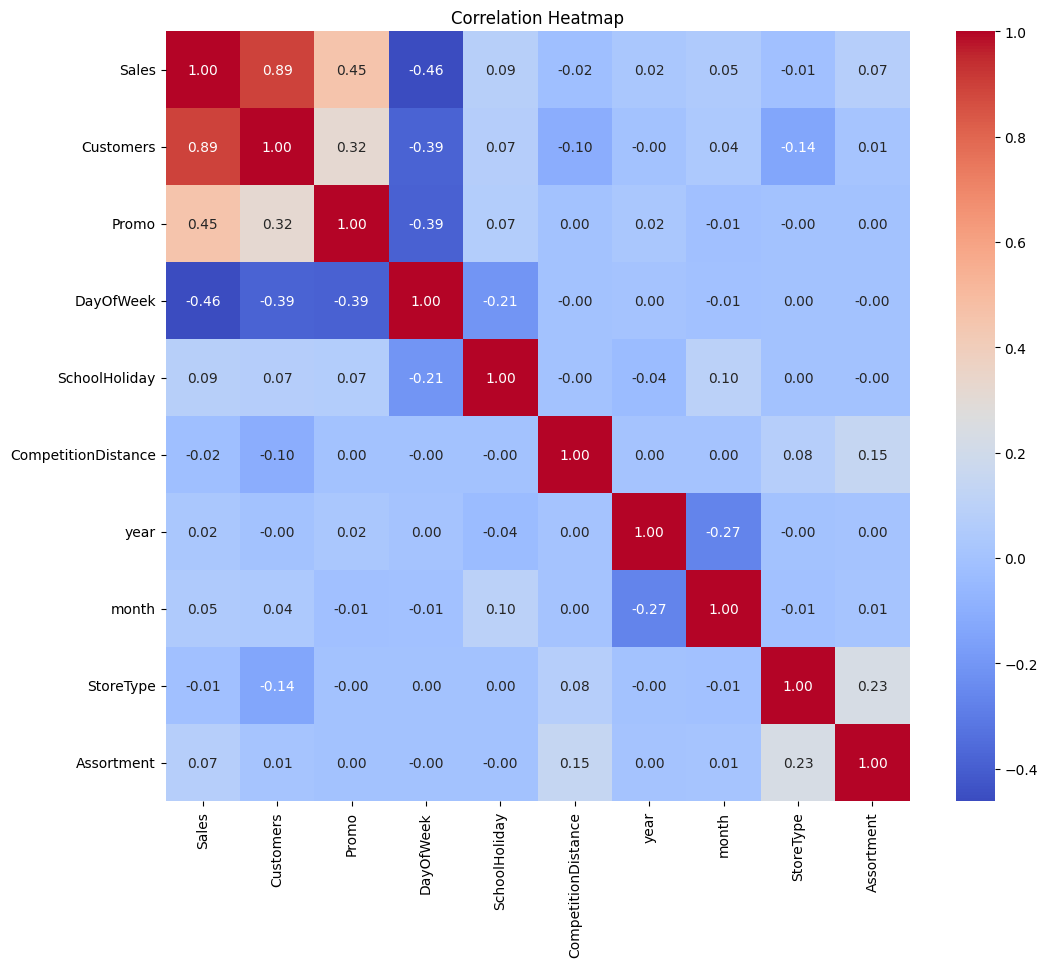

In [89]:
plt.figure(figsize=(12, 10))
# Selecting a subset of features for a cleaner heatmap
corr_cols = ['Sales', 'Customers', 'Promo', 'DayOfWeek', 'SchoolHoliday',
             'CompetitionDistance', 'year', 'month', 'StoreType', 'Assortment']
corr = merged_df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

[0]	validation_0-rmse:3559.64275
[100]	validation_0-rmse:1401.65297
[200]	validation_0-rmse:1070.70928
[300]	validation_0-rmse:972.68088
[400]	validation_0-rmse:920.84648
[500]	validation_0-rmse:892.45075
[600]	validation_0-rmse:873.80565
[700]	validation_0-rmse:863.87870
[800]	validation_0-rmse:857.24195
[900]	validation_0-rmse:851.00248
[999]	validation_0-rmse:847.10846
Validation RMSE: 845.73


<Figure size 1000x800 with 0 Axes>

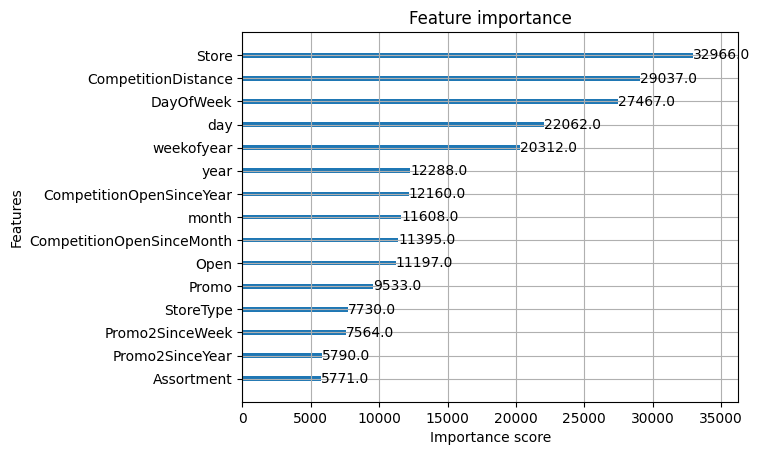

In [92]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Prepare features: removing target, customers (leaky), and date
features = merged_df.drop(['Sales', 'Customers', 'Date', 'CustomerSpendings', 'PromoInterval'], axis=1)
target = merged_df['Sales']

# Time-based split (last 6 weeks for validation)
cutoff = '2015-06-15'
train_idx = merged_df['Date'] < cutoff
val_idx = merged_df['Date'] >= cutoff

X_train, X_val = features[train_idx], features[val_idx]
y_train, y_val = target[train_idx], target[val_idx]

# Train XGBoost Model
model = xgb.XGBRegressor(
    n_estimators=1000,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    objective='reg:squarederror',
    early_stopping_rounds=50
)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

# Evaluate
y_pred = model.predict(X_val)
y_pred = np.maximum(y_pred, 0)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print(f'Validation RMSE: {rmse:.2f}')

# Feature Importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(model, max_num_features=15)
plt.show()

In [93]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.5 MB/s eta 0:00:00


In [94]:
import optuna

def objective(trial):
    param = {
        'n_estimators': 500,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'objective': 'reg:squarederror',
        'n_jobs': -1,
        'early_stopping_rounds': 50
    }

    model = xgb.XGBRegressor(**param)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    preds = model.predict(X_val)
    preds = np.maximum(preds, 0)
    rmse = np.sqrt(mean_squared_error(y_val, preds))
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial
print("  Value: ", trial.value)
print("  Params: ")
for key, value in trial.params.items():
    print("    {}: {}".format(key, value))

[I 2026-06-25 20:08:18,861] A new study created in memory with name: no-name-80c8df09-0477-4eca-a73e-a7af523059df
[I 2026-06-25 20:09:37,186] Trial 0 finished with value: 1996.500876533742 and parameters: {'max_depth': 5, 'learning_rate': 0.02202918942051444, 'subsample': 0.9811724037761818, 'colsample_bytree': 0.6496995149113467}. Best is trial 0 with value: 1996.500876533742.
[I 2026-06-25 20:10:33,609] Trial 1 finished with value: 1740.1441750613653 and parameters: {'max_depth': 5, 'learning_rate': 0.0386961026365127, 'subsample': 0.7372154172755739, 'colsample_bytree': 0.5599113830688272}. Best is trial 1 with value: 1740.1441750613653.
[I 2026-06-25 20:11:25,804] Trial 2 finished with value: 1047.8017465150551 and parameters: {'max_depth': 5, 'learning_rate': 0.22635747882526172, 'subsample': 0.9966360861567503, 'colsample_bytree': 0.6403906613337189}. Best is trial 2 with value: 1047.8017465150551.
[I 2026-06-25 20:12:13,979] Trial 3 finished with value: 2072.018580997767 and par

Number of finished trials:  20
Best trial:
  Value:  868.4825127773155
  Params: 
    max_depth: 8
    learning_rate: 0.1326836469435823
    subsample: 0.5771903251928809
    colsample_bytree: 0.6941066954361761


In [95]:
best_params = study.best_params
best_params['n_estimators'] = 1000
best_params['objective'] = 'reg:squarederror'
best_params['early_stopping_rounds'] = 50

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=100)

final_preds = final_model.predict(X_val)
final_preds = np.maximum(final_preds, 0)
final_rmse = np.sqrt(mean_squared_error(y_val, final_preds))

print(f'Optimized Validation RMSE: {final_rmse:.2f}')

[0]	validation_0-rmse:3504.05351
[100]	validation_0-rmse:1270.88510
[200]	validation_0-rmse:1002.50979
[300]	validation_0-rmse:922.05440
[400]	validation_0-rmse:891.19174
[500]	validation_0-rmse:870.80550
[600]	validation_0-rmse:862.41436
[700]	validation_0-rmse:851.99072
[793]	validation_0-rmse:850.77616
Optimized Validation RMSE: 848.14


### Final Pipeline Integration
We will now wrap the feature engineering and modeling into a structured pipeline. This ensures that the same transformations applied to the training data are consistently applied to any new data (like the test set).

In [97]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

class RossmannFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.le_dict = {}
        self.categorical_cols = ['StoreType', 'Assortment', 'StateHoliday']
        self.all_months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    def fit(self, X, y=None):
        for col in self.categorical_cols:
            le = LabelEncoder()
            le.fit(X[col].astype(str))
            self.le_dict[col] = le
        return self

    def transform(self, X):
        X = X.copy()
        X['Date'] = pd.to_datetime(X['Date'])
        X['year'] = X['Date'].dt.year
        X['month'] = X['Date'].dt.month
        X['day'] = X['Date'].dt.day
        X['weekofyear'] = X['Date'].dt.isocalendar().week.astype(int)

        X['PromoInterval'] = X['PromoInterval'].fillna('None')
        dummies = X['PromoInterval'].str.get_dummies(sep=',').reindex(columns=self.all_months, fill_value=0)
        X = X.join(dummies)

        for col, le in self.le_dict.items():
            X[col] = le.transform(X[col].astype(str))

        X['CompetitionDistance'] = X['CompetitionDistance'].fillna(X['CompetitionDistance'].mean())
        X['CompetitionOpenSinceMonth'] = X['CompetitionOpenSinceMonth'].fillna(X['CompetitionOpenSinceMonth'].mean())
        X['CompetitionOpenSinceYear'] = X['CompetitionOpenSinceYear'].fillna(X['CompetitionOpenSinceYear'].mean())
        X['Promo2SinceWeek'] = X['Promo2SinceWeek'].fillna(X['Promo2SinceWeek'].mean())
        X['Promo2SinceYear'] = X['Promo2SinceYear'].fillna(X['Promo2SinceYear'].mean())

        drop_cols = ['Date', 'Customers', 'Sales', 'CustomerSpendings', 'PromoInterval', 'Id']
        X.drop(columns=[c for c in drop_cols if c in X.columns], inplace=True)
        return X

# Create a copy of best_params without early stopping for the pipeline
pipeline_params = best_params.copy()
if 'early_stopping_rounds' in pipeline_params:
    del pipeline_params['early_stopping_rounds']

rossmann_pipeline = Pipeline([
    ('feature_eng', RossmannFeatureExtractor()),
    ('model', xgb.XGBRegressor(**pipeline_params))
])

raw_train = pd.merge(train_df, store, on='Store', how='left')
rossmann_pipeline.fit(raw_train, raw_train['Sales'])
print('Integrated Pipeline training complete.')

Integrated Pipeline training complete.


In [99]:
raw_test = pd.merge(test_df, store, on='Store', how='left')

# Generate predictions
test_preds = rossmann_pipeline.predict(raw_test)

# Post-process: Ensure no negative sales and add to a results DataFrame
raw_test['Sales_Prediction'] = np.maximum(test_preds, 0)

# Display the results
display(raw_test[['Id', 'Store', 'Date', 'Sales_Prediction']].head())

# Optional: Save to CSV
# raw_test[['Id', 'Sales_Prediction']].to_csv('rossmann_predictions.csv', index=False)

,Id,Store,Date,Sales_Prediction
0,1,1,2015-09-17,4198.832520
1,2,3,2015-09-17,7402.876953
2,3,7,2015-09-17,9072.796875
3,4,8,2015-09-17,7190.416504
4,5,9,2015-09-17,7325.895020


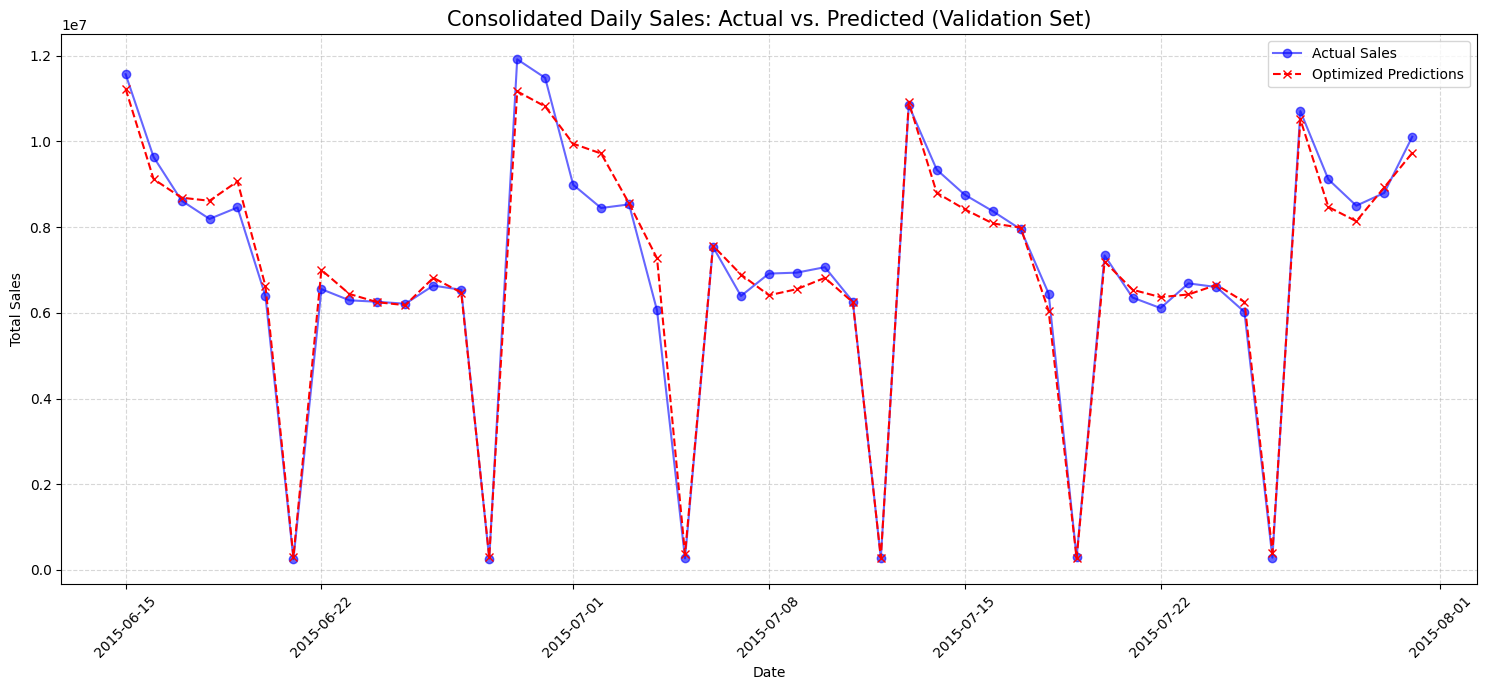

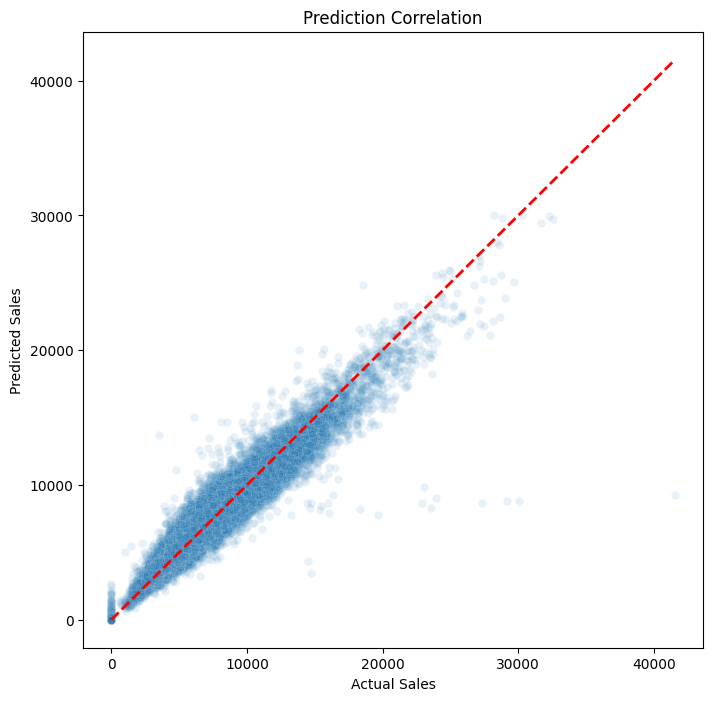

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for plotting
plot_df = merged_df[val_idx].copy()
plot_df['Actual_Sales'] = y_val
plot_df['Predicted_Sales'] = final_preds

# Group by date to see the aggregate performance across all stores
daily_sales = plot_df.groupby('Date')[['Actual_Sales', 'Predicted_Sales']].sum().reset_index()

plt.figure(figsize=(15, 7))
plt.plot(daily_sales['Date'], daily_sales['Actual_Sales'], label='Actual Sales', color='blue', marker='o', alpha=0.6)
plt.plot(daily_sales['Date'], daily_sales['Predicted_Sales'], label='Optimized Predictions', color='red', linestyle='--', marker='x')

plt.title('Consolidated Daily Sales: Actual vs. Predicted (Validation Set)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Also plot a scatter for correlation
plt.figure(figsize=(8, 8))
sns.scatterplot(x='Actual_Sales', y='Predicted_Sales', data=plot_df, alpha=0.1)
plt.plot([0, plot_df['Actual_Sales'].max()], [0, plot_df['Actual_Sales'].max()], color='red', lw=2, linestyle='--')
plt.title('Prediction Correlation')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()